Relação estado reuso: 
{2: 3, 3: 2, 4: 1}


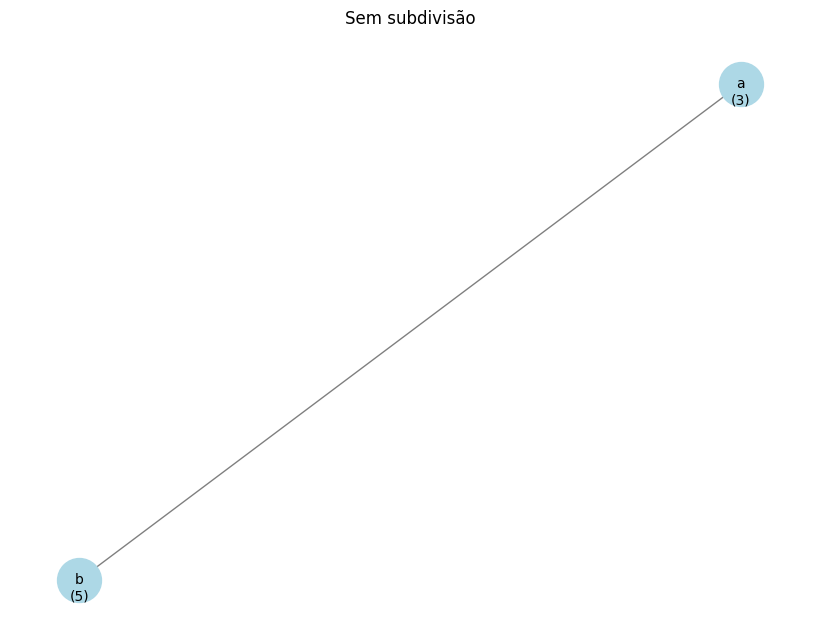

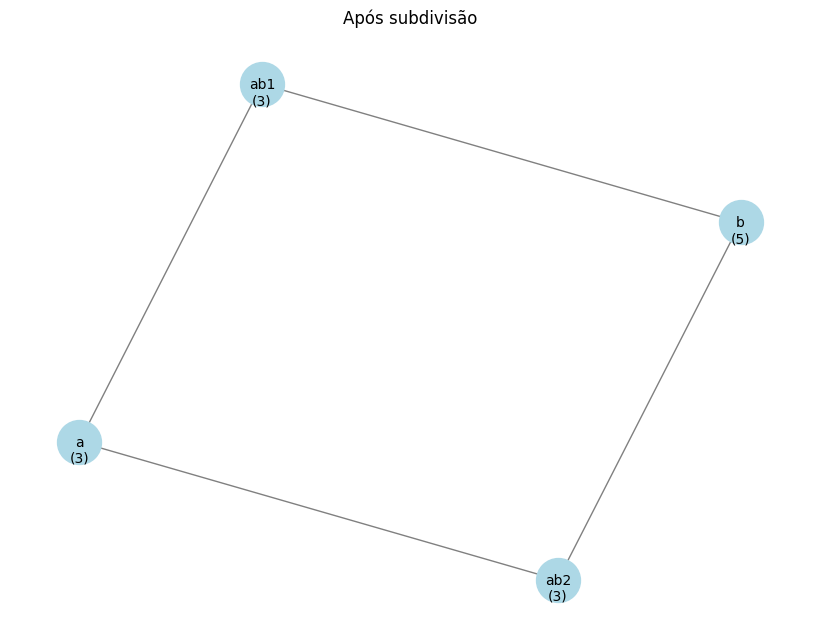

Iniciou às 2025-11-07 10:58:33.008
aaaa
aaaa
aaaa
aaaa
aaaa

Com Programação Dinâmica :
Melhor caminho: ['b', 'a']
Tempo de execução: 0.00029468536376953125 segundos
Quantidade de estados  a serem gerados: 1
Número de entradas na tabela dinâmica: 1
Tamanho total do memo (real): 536 bytes
Número de reusos: 123139
Número de estados distintos usados:  22501

Vértices escolhidos por Ana: ['b']
Ganho de Ana: 5

Vértices escolhidos por Bob: ['a']
Ganho de Bob: 3

Estados Reutilizados:
('d', 'cd2') → reutilizado 5 vezes
Caminho percorrido: [('a', 'ab1', 'ab2', 'b', 'ac1', 'ac2', 'ad1', 'ad2', 'bc1', 'bc2', 'c', 'bd1', 'cd1', 'bd2'), ('a', 'ab1', 'ab2', 'b', 'ac1', 'ac2', 'ad1', 'ad2', 'bc1', 'bc2', 'c', 'bd2', 'cd1', 'bd1'), ('a', 'ab1', 'ab2', 'b', 'ac1', 'ac2', 'ad1', 'ad2', 'bc1', 'bc2', 'bd1', 'bd2', 'cd1', 'c'), ('a', 'ab1', 'ab2', 'b', 'ac1', 'ac2', 'ad1', 'bc1', 'bc2', 'c', 'bd1', 'bd2', 'cd1', 'ad2'), ('a', 'ab1', 'ab2', 'b', 'ac1', 'ac2', 'ad2', 'bc1', 'bc2', 'c', 'bd1', 'bd2', 'cd1'

IOPub data rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_data_rate_limit`.

Current values:
ServerApp.iopub_data_rate_limit=1000000.0 (bytes/sec)
ServerApp.rate_limit_window=3.0 (secs)



In [2]:
from geracao_grafos import *
from problemasPolinomiais.gulosoBicoloridoCiclo import *
from problemasPolinomiais.gulosoCompleto import *
from problemasPolinomiais.gulosoKmn import *
from problemasPolinomiais.gulosoArvore import *
from funcoesDP import *
from valG import *
from pympler import asizeof
#!pip install pympler

from otimizacoesPD.caminho_otimizado_pd import *
import gc
import sys


def mainSemDp(grafo, pesos):
    
    inicio_tempo = time.time()
    melhor_valor, melhor_caminho = valor(grafo, pesos)
    fim_tempo = time.time()
    print("Sem Programação Dinâmica:")
    print("Melhor caminho:", melhor_caminho)
    print("Tempo de execução:", fim_tempo - inicio_tempo, "segundos")
    calcular_ganhos(melhor_caminho, pesos)
    imprimirArvoreDecisao(arvore_decisao,False)


def w3():
    G = nx.Graph()
    edges = [('a', 'b'), ('b', 'c'),('a', 'c'),('a', 'd'), ('b', 'd'),('c', 'd') ]
    #edges = [('v4', 'v3'), ('v3', 'v2'), ('v2', 'v1')]

    G.add_edges_from(edges)
    weights = {'a': 3, 'b': 5, 'c': 1,'d':2}

    return G,weights


def P2():
    G = nx.Graph()
    edges = [('a', 'b') ]
    #edges = [('v4', 'v3'), ('v3', 'v2'), ('v2', 'v1')]

    G.add_edges_from(edges)
    weights = {'a': 3, 'b': 5}

    return G,weights

def mainDP(grafo, pesos):
    inicio_tempo = time.time()
    memo = {}
    timestamp = datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S.%f")[:-3]  # Mantém milissegundos
  # Captura o instante de reutilização
    print(f"Iniciou às {timestamp}")
    melhor_valor_dp, melhor_caminho_dp = valor_dp(grafo, pesos, memo,inicio_tempo)
    fim_tempo = time.time()
    print("\nCom Programação Dinâmica :")
    print("Melhor caminho:", melhor_caminho_dp)
    print("Tempo de execução:", fim_tempo - inicio_tempo, "segundos")
    quantidade_estados = contar_estados(grafo)
    print("Quantidade de estados  a serem gerados:", quantidade_estados)
    print("Número de entradas na tabela dinâmica:", len(memo))
    print("Tamanho total do memo (real):", asizeof.asizeof(memo), "bytes")
    print("Número de reusos:", len(contagem_reuso_dp))
    print("Número de estados distintos usados: ",len(estados_reusados))
    calcular_ganhos(melhor_caminho_dp, pesos)
    imprime_estados_reusados()
    imprime_estados_nao_reutilizados(memo)
    #imprime_tabela_dp(memo)

    return logs_memo,qtd_estados_plot
    #imprimirArvoreDecisao(arvore_decisao_dp)

def mainDP_Bipartido(grafo, pesos,m,n):
    inicio_tempo = time.time()
    memo = {}
    timestamp = datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S.%f")[:-3]  # Mantém milissegundos
  # Captura o instante de reutilização
    print(f"Iniciou às {timestamp}")
    melhor_valor_dp, melhor_caminho_dp = valor_dp_bipartido(grafo, pesos, memo,m,n,inicio_tempo)
    #melhor_valor_dp, melhor_caminho_dp = valor_dp_bipartido_LIMPO(grafo, pesos, memo,m,n)
    fim_tempo = time.time()
    print("\nCom Programação Dinâmica Kmn Otimizado:")
    print("Melhor caminho:", melhor_caminho_dp)
    print("Tempo de execução:", fim_tempo - inicio_tempo, "segundos")
    quantidade_estados = contar_estados(grafo)
    print("Quantidade de estados  a serem gerados:", quantidade_estados)
    print("Número de entradas na tabela dinâmica:", len(memo))
    print("Tamanho total do memo (real):", asizeof.asizeof(memo), "bytes")
    print("Número de reusos:", len(contagem_reuso_dp))
    print("Número de estados distintos usados: ",len(estados_reusados))
    calcular_ganhos(melhor_caminho_dp, pesos)
    #imprime_estados_reusados()
    #imprime_estados_nao_reutilizados(memo)
    return logs_memoKmn,qtd_estados_plotKmn
    #imprime_tabela_dp(memo)
    #imprimirArvoreDecisao(arvore_decisao_dp)


def mainDP_Caminho(grafo, pesos):
    primeirosVerticesViaveis = verticesViaveis(grafo)
    primeirosVerticesNaoViaveis = grafo.nodes - primeirosVerticesViaveis

    inicio_tempo = time.time()
    memo = {}
    timestamp = datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S.%f")[:-3]  # Mantém milissegundos
  # Captura o instante de reutilização
    print(f"Iniciou às {timestamp}")
    melhor_valor_dp, melhor_caminho_dp = valor_dp_caminho(grafo, pesos, primeirosVerticesNaoViaveis,memo,inicio_tempo)
    #melhor_valor_dp, melhor_caminho_dp = valor_dp_caminho_LIMPO(grafo, pesos, primeirosVerticesNaoViaveis,memo)

    
    fim_tempo = time.time()
    print("\nCom Programação Dinâmica Pn Otimizado:")
    print("Melhor caminho:", melhor_caminho_dp)
    print("Tempo de execução:", fim_tempo - inicio_tempo, "segundos")
    quantidade_estados = contar_estados(grafo)
    print("Quantidade de estados  a serem gerados:", quantidade_estados)
    print("Número de entradas na tabela dinâmica:", len(memo))
    print("Tamanho total do memo (real):", asizeof.asizeof(memo), "bytes")
    print("Número de reusos:", len(contagem_reuso_dp))
    print("Número de estados distintos usados: ",len(estados_reusados))
    calcular_ganhos(melhor_caminho_dp, pesos)
    imprime_estados_reusados()
    imprime_estados_nao_reutilizados(memo)
    return logs_memoKmn,qtd_estados_plotKmn
    #imprime_tabela_dp(memo)
    #imprimirArvoreDecisao(arvore_decisao_dp)


def subdivisao_losango(G, weights):
    """
    Aplica subdivisão losango em cada aresta (u, v):
        u — uv1 — v
        u — uv2 — v
    Os novos vértices uv1 e uv2 recebem o peso do menor entre
    weights[u] e weights[v].
    """
    G_sub = nx.Graph()
    new_weights = {}

    # Mantém os vértices originais e seus pesos
    for node, w in weights.items():
        new_weights[node] = w

    # Para cada aresta, cria o losango com pesos herdados do menor vértice
    for u, v in G.edges():
        mid1 = f"{u}{v}1"
        mid2 = f"{u}{v}2"

        # Peso herdado do menor entre u e v
        menor_peso = min(weights[u], weights[v])

        # Adiciona arestas do losango
        G_sub.add_edges_from([
            (u, mid1), (mid1, v),
            (u, mid2), (mid2, v)
        ])

        # Define pesos
        new_weights[mid1] = menor_peso
        new_weights[mid2] = menor_peso

    return G_sub, new_weights

def main():
    gc.collect()  # Força a coleta de lixo
    m, n = 3,3
    altura = 3
    gerar_reuso_estados(m, n)

    #grafo, pesos = grafoSimples()
    
    #grafo, pesos = gerar_grafo_ciclo(6)      # Gera um ciclo de 5 nós
    #grafo, pesos = gerar_grafo_completo(13)   # Gera um grafo completo de 6 nós
    #grafo, pesos = gerar_grafo_caminho(20)    # Gera um caminho de 4 nós
    
    #grafo, pesos, conjunto_x, conjunto_y = criar_grafo_bipartido(m, n)
    #grafo, pesos, conjunto_x, conjunto_y = criar_grafo_bipartido_completo(m, n)

    #grafo, pesos = gerar_arvore_par(16)    
    #grafo, pesos = arvoreCompleta(altura)
    #grafo, pesos = w3() 
    #mainGulosoKmn(grafo,pesos)
    #mainGulosoArvore(grafo,pesos)

    #mainDP( grafo, pesos)
    contagem_reuso_dp = []
    
    print("==================================================================================================")
    print("==================================================================================================")
    #mainDP_Bipartido(grafo,pesos,m,n)
    #mainDP_Caminho(grafo,pesos)
    print("==================================================================================================")
    print("==================================================================================================")
    #plotar_evolucao_memo(logs_memo,logs_memoKmn)
    #plotar_evolucaoQtdEstados_memo(qtd_estados_plot,qtd_estados_plotKmn)
    grafo, pesos = P2()
    #grafo, pesos = c4()
    plot_graph(grafo, pesos,'Sem subdivisão')
    grafoLosango, pesosLosango = subdivisao_losango(grafo, pesos)
    plot_graph(grafoLosango, pesosLosango,'Após subdivisão')

    mainDP( grafo, pesos)
    #mainDP( grafoLosango, pesosLosango)
    #mainSemDp( grafo, pesos)
    #mainBicoloracaoCaminho( grafo, pesos)
    #mainGulosoCompleto(grafo,pesos)
    #mainGulosoBicoloridoCiclo(grafo,pesos)

if __name__ == "__main__":
    main()